In [2]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import jax
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="0"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

2025-03-13 16:55:11.179532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741884911.191853 1239122 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741884911.195771 1239122 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [4]:
jax.devices()

[CudaDevice(id=0)]

In [5]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)

num_stars = 100

I0000 00:00:1741884914.551951 1239122 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17510 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


In [6]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at al

seed = 42

df_train = df.sample(frac=0.95, random_state=seed)

df_test = df.drop(df_train.index)

#hare_idx = 1070114

hare_idx = 998424

massini = df_test.loc[hare_idx, 'massini']

zini = df_test.loc[hare_idx, 'zini']

yini = df_test.loc[hare_idx, 'yini']

alphaMLT = df_test.loc[hare_idx, 'alphaMLT']

eta = df_test.loc[hare_idx, 'eta']

alphaFe = df_test.loc[hare_idx, 'alphaFe']

age = df_test.loc[hare_idx, 'age']

track_indices = df_test.loc[998069:998920].index

In [15]:
df_test[(df_test['alphaFe'] == 0.3)&(df_test['massini'] < 1)&(df_test['FeH']>-1.1)&(df_test['FeH']<-0.9)&(df_test['massini']>0.85)&(df_test['alphaMLT']>1.8)&(df_test['age'] > 10000)].sort_values(by = 'yini')

,massini,zini,yini,alphaMLT,age,eta,alphaFe,FeH,LPhot,Teff,numax,dnuSer,logLPhot
1847989,0.896,0.002002,0.250374,2.283789,10001.07886,0.249683,0.3,-1.036879,25.450899,5324.070782,0.026312,0.064104,1.405703
1847994,0.896,0.002002,0.250374,2.283789,10003.12655,0.249683,0.3,-1.036839,26.043702,5319.771021,0.025640,0.062788,1.415703
1847996,0.896,0.002002,0.250374,2.283789,10003.92872,0.249683,0.3,-1.036819,26.281755,5318.069900,0.025379,0.062301,1.419654
1848019,0.896,0.002002,0.250374,2.283789,10012.43472,0.249683,0.3,-1.036698,29.057773,5298.923467,0.022661,0.057096,1.463262
1848030,0.896,0.002002,0.250374,2.283789,10016.09392,0.249683,0.3,-1.036678,30.418553,5289.905476,0.021517,0.054829,1.483139
1848058,0.896,0.002002,0.250374,2.283789,10024.37882,0.249683,0.3,-1.036658,33.957379,5267.912177,0.018991,0.049751,1.530934
1848070,0.896,0.002002,0.250374,2.283789,10027.57533,0.249683,0.3,-1.036658,35.521523,5258.667245,0.018041,0.047794,1.550492
1848073,0.896,0.002002,0.250374,2.283789,10028.34174,0.249683,0.3,-1.036658,35.916872,5256.383518,0.017815,0.047337,1.555299
1848089,0.896,0.002002,0.250374,2.283789,10032.20445,0.249683,0.3,-1.036658,38.045568,5244.378231,0.016682,0.044977,1.580304
1848099,0.896,0.002002,0.250374,2.283789,10034.45558,0.249683,0.3,-1.036658,39.401865,5236.976545,0.016027,0.043623,1.595517


In [20]:
prior_values = [massini, zini, yini, alphaMLT, age, eta, alphaFe]

prior_widths = [0.1, 0.1, 0.1, 0.1, 1000, 0.01, 0.01]



priors = [(prior_values[i], prior_widths[i]) for i in range(len(prior_values))]

cluster_consts = {}

for key, value in zip(model_outputs.inputs, priors):
    if key not in cluster_consts:
        cluster_consts[key] = value
    else:
        cluster_consts[key].append(value)

cluster_consts


{'massini': (np.float64(0.818), 0.1),
 'zini': (np.float64(0.0018053829999999382), 0.1),
 'yini': (np.float64(0.269321289), 0.1),
 'alphaMLT': (np.float64(2.00976562), 0.1),
 'age': (np.float64(12208.44093), 1000),
 'eta': (np.float64(0.0435058594), 0.01),
 'alphaFe': (np.float64(0.2), 0.01)}

In [7]:
fake_obs = {'FeH':df_test.loc[hare_idx, 'FeH'], 'LPhot':df_test.loc[hare_idx, 'LPhot'], 'Teff':df_test.loc[hare_idx, 'Teff'], 'numax':df_test.loc[hare_idx, 'numax'], 'dnuSer':df_test.loc[hare_idx, 'dnuSer'], 'logLPhot':df_test.loc[hare_idx, 'logLPhot']}

# Make a fake cluster

In [8]:
def fake_stars(uncs, consts = cluster_consts, obs = model_outputs.obs_dict):

    with numpyro.plate("star", 1):

        age = numpyro.sample('age', dist.Normal(consts['age'][0], consts['age'][1]))

        tau = sample_beta('tau', 1, 0.1, alpha = 10, beta = 10)

        massini = numpyro.deterministic ('massini', (0.6426*10**4/age)**(1/3.2))

        zini = numpyro.sample('zini', dist.LogNormal(np.log(consts['zini'][0]), consts['zini'][1]))

        yini = numpyro.sample('yini', dist.LogNormal(np.log(consts['yini'][0]), consts['yini'][1]))

        alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(consts['alphaMLT'][0],consts['alphaMLT'][1], low = 1.5, high = 2.3))

        eta = numpyro.sample('eta', dist.Normal(consts['eta'][0], consts['eta'][1]))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(consts['alphaFe'][0], consts['alphaFe'][1]))
               
        params = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

        pred = model_outputs(params)

 #       numaxtest = numpyro.sample('numaxtest', dist.Normal(30, 9))


    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    logLPhot = numpyro.sample("logLPhot", dist.LogNormal(jnp.log(pred[:, 1]), uncs['logLPhot']), obs=obs['logLPhot'])

    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(pred[:, 3], uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(pred[:, 4], uncs['dnuSer']), obs=obs['dnuSer'])
 





In [9]:
num_warmup, num_samples = 1000, 1000

num_chains = 1

sampler = NUTS(fake_stars, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [10]:
phys_unc = {'Teff':150, 'LPhot':10, 'numax': 10/3090, 'dnuSer':1/135, 'FeH':0.1, 'logLPhot':0.05}

In [11]:
fake_obs

{'FeH': np.float64(-0.9948869592058154),
 'LPhot': np.float64(43.77328471138846),
 'Teff': np.float64(5067.356016),
 'numax': np.float64(0.011779638063650807),
 'dnuSer': np.float64(0.034780172484049646),
 'logLPhot': np.float64(1.6412091369376838)}

In [12]:
mcmc.run(jax.random.PRNGKey(0),  uncs=phys_unc, obs=fake_obs)

mcmc.print_summary()

sample: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [02:08<00:00, 15.58it/s, 255 steps of size 2.09e-02. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
     age[0]  12029.97    992.24  12021.70  10283.16  13456.86    417.06      1.00
 alphaFe[0]      0.20      0.01      0.20      0.18      0.22    704.20      1.00
alphaMLT[0]      1.98      0.07      1.98      1.86      2.10    656.40      1.00
     eta[0]      0.04      0.01      0.04      0.03      0.06    599.06      1.01
tau_beta[0]      0.50      0.11      0.50      0.30      0.66    713.65      1.00
    yini[0]      0.27      0.00      0.27      0.26      0.27    398.94      1.00
    zini[0]      0.00      0.00      0.00      0.00      0.00    515.70      1.00

Number of divergences: 0


In [13]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

prior_predictive = Predictive(fake_stars, num_samples=1000,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

In [14]:
np.std(prior['zini'].T[0])/np.mean(prior['zini'].T[0])

Array(0.10525286, dtype=float64)

In [15]:
np.log(1.5)*0.00180538

np.float64(0.0007320185968763179)

In [16]:
posterior = mcmc.get_samples(group_by_chain=True)
sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))
posterior_predictive = Predictive(fake_stars, posterior_samples=posterior, parallel=True, batch_ndims=2)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)

In [17]:
params = jnp.stack([posterior['massini'][0].T, posterior['zini'][0].T, posterior['yini'][0].T, posterior['alphaMLT'][0].T, posterior['age'][0].T, posterior['eta'][0].T, posterior['alphaFe'][0].T], axis = -1)

pred = model_outputs(params)


(array([  3.,  33., 125., 221., 304., 200.,  52.,  34.,  22.,   6.]),
 array([ 9039.43229105,  9711.15096945, 10382.86964786, 11054.58832626,
        11726.30700466, 12398.02568306, 13069.74436147, 13741.46303987,
        14413.18171827, 15084.90039668, 15756.61907508]),
 <BarContainer object of 10 artists>)

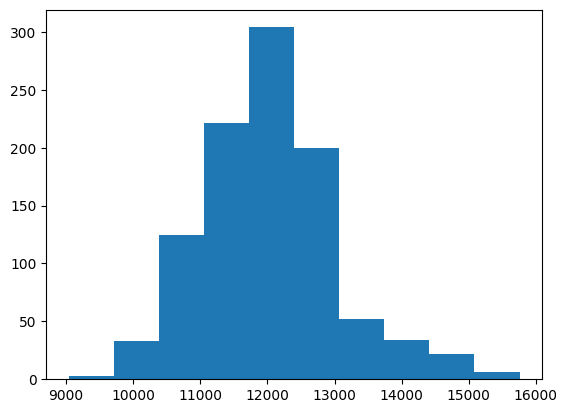

In [18]:
plt.hist(posterior['age'].T[0])

In [24]:
np.std(posterior['zini'].T[0])

Array(0.00016017, dtype=float64)

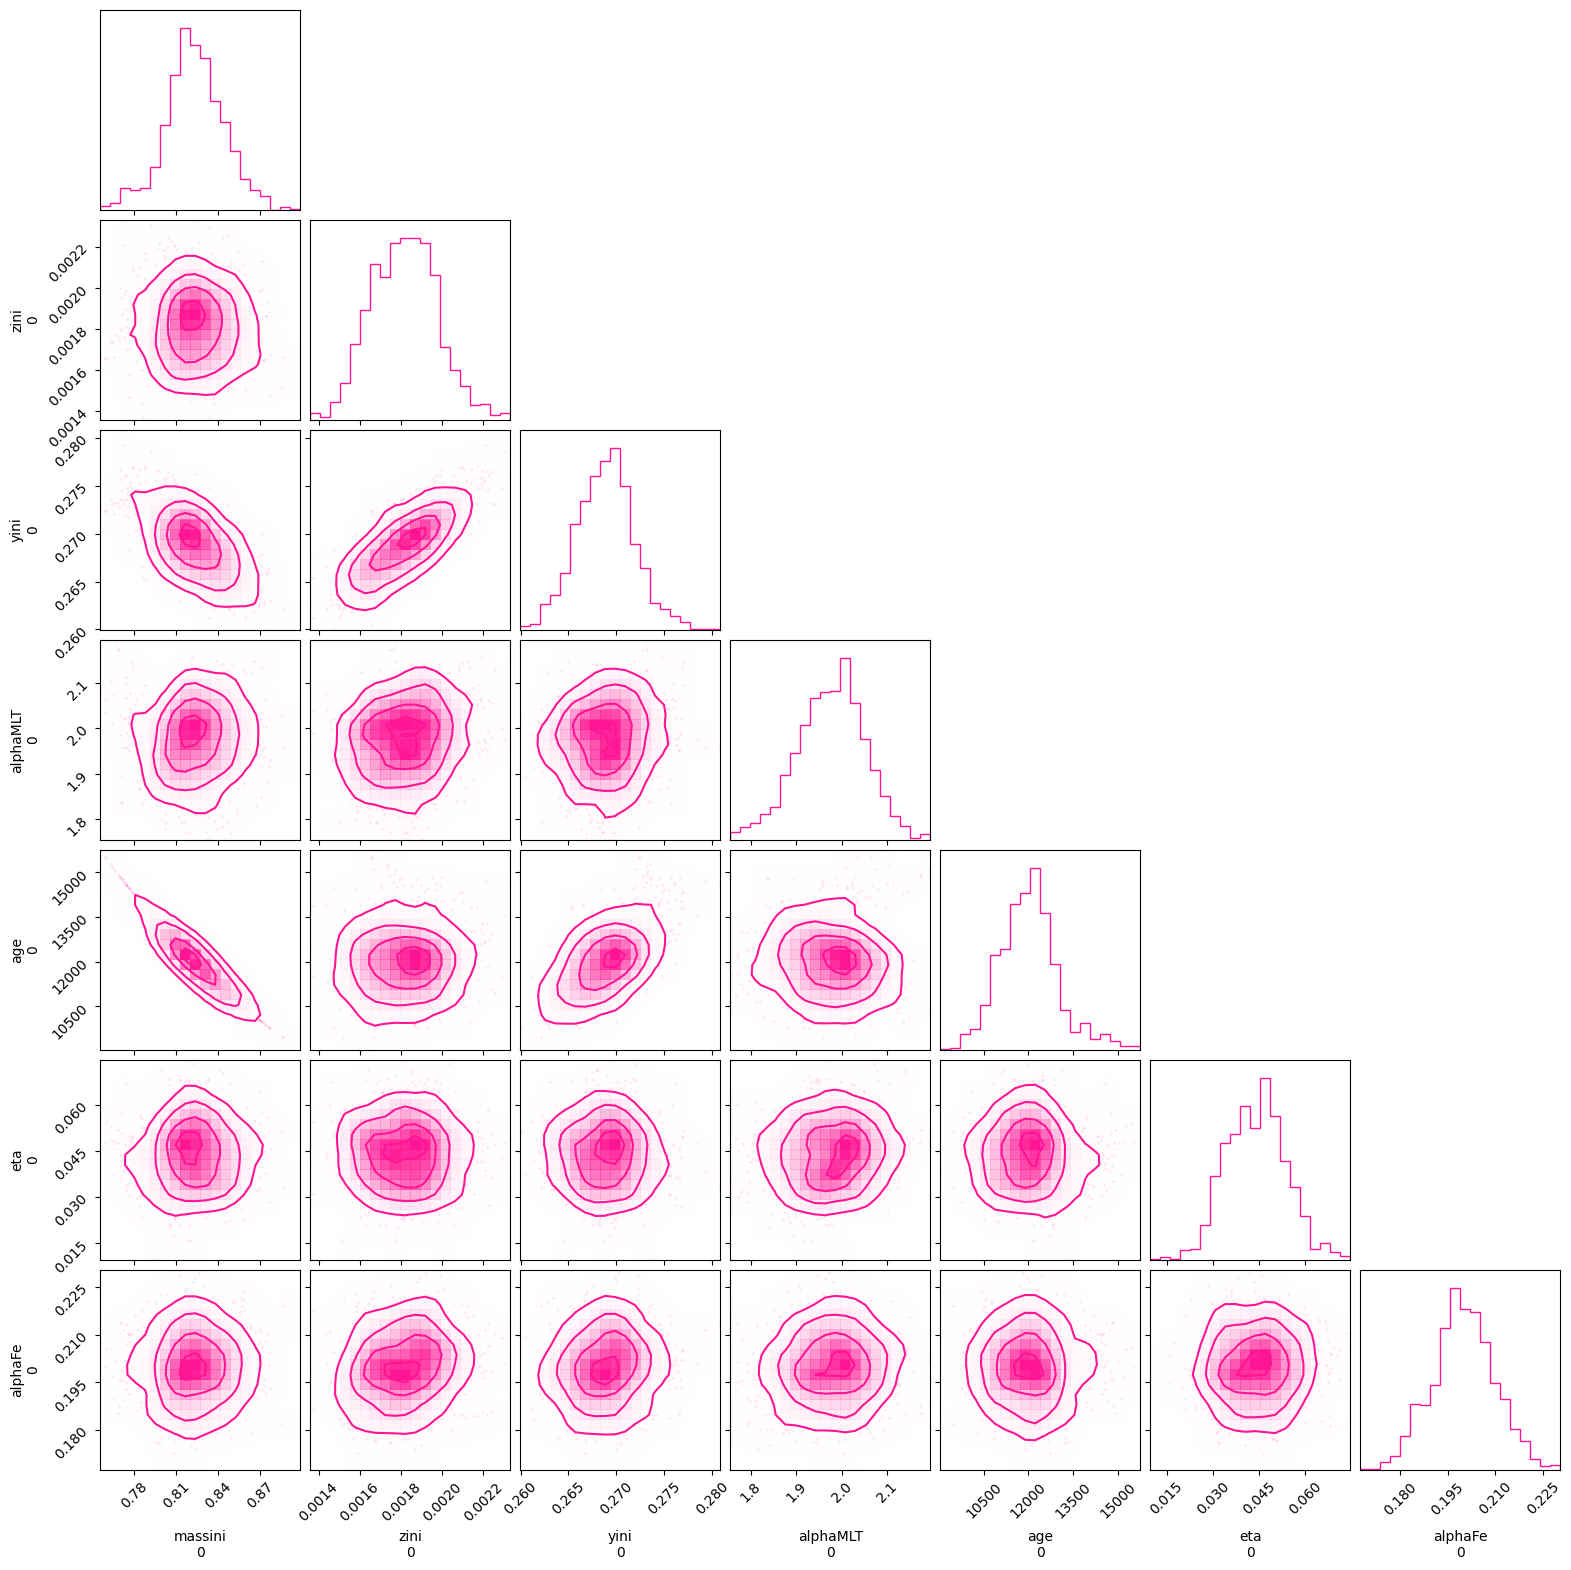

In [21]:
fig = corner.corner(data, group="posterior", var_names = model_outputs.inputs,  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True)
#corner.corner(df_test[model_outputs.inputs],zorder = 0, alpha = 0.1, fig = fig, smooth = True)
fig.savefig('../figs/fake-cluster-observations-from-one-hare-corner.png', bbox_inches = 'tight')
plt.show()


In [22]:
cluster_df = pd.DataFrame(columns = df_test.columns)

cluster_df['FeH'] = pred[0].T[0]

cluster_df['logLPhot'] = pred[0].T[1]

cluster_df['Teff'] = pred[0].T[2]

cluster_df['numax'] = pred[0].T[3]

cluster_df['dnuSer'] = pred[0].T[4]

cluster_df['massini'] = posterior['massini'][0].T[0]

cluster_df['zini'] = posterior['zini'][0].T[0]

cluster_df['yini'] = posterior['yini'][0].T[0]

cluster_df['alphaMLT'] = posterior['alphaMLT'][0].T[0]

cluster_df['alphaFe'] = posterior['alphaFe'][0].T[0]

cluster_df['age'] = posterior['age'][0].T[0]

cluster_df['eta'] = posterior['eta'][0].T[0]

draws = cluster_df.sample(30)

draws.to_csv('./fake-data/fake-cluster-observations-from-one-hare.csv', index = False)

np.save('./fake-data/fake-cluster-observations-from-one-hare-consts.npy', cluster_consts)

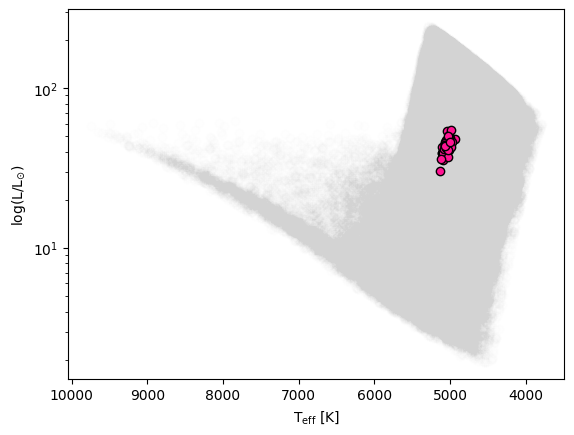

In [23]:
plt.scatter(df_test['Teff'], 10**df_test['logLPhot'], color = 'lightgrey', alpha = 0.01)
plt.scatter(draws['Teff'], 10**draws['logLPhot'], facecolor = 'deeppink', edgecolor = 'black')
plt.gca().invert_xaxis()
plt.semilogy()
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'log(L/L$_{\odot}$)')
plt.savefig('../figs/fake-cluster-observations-from-one-hare-HR.png', bbox_inches = 'tight')

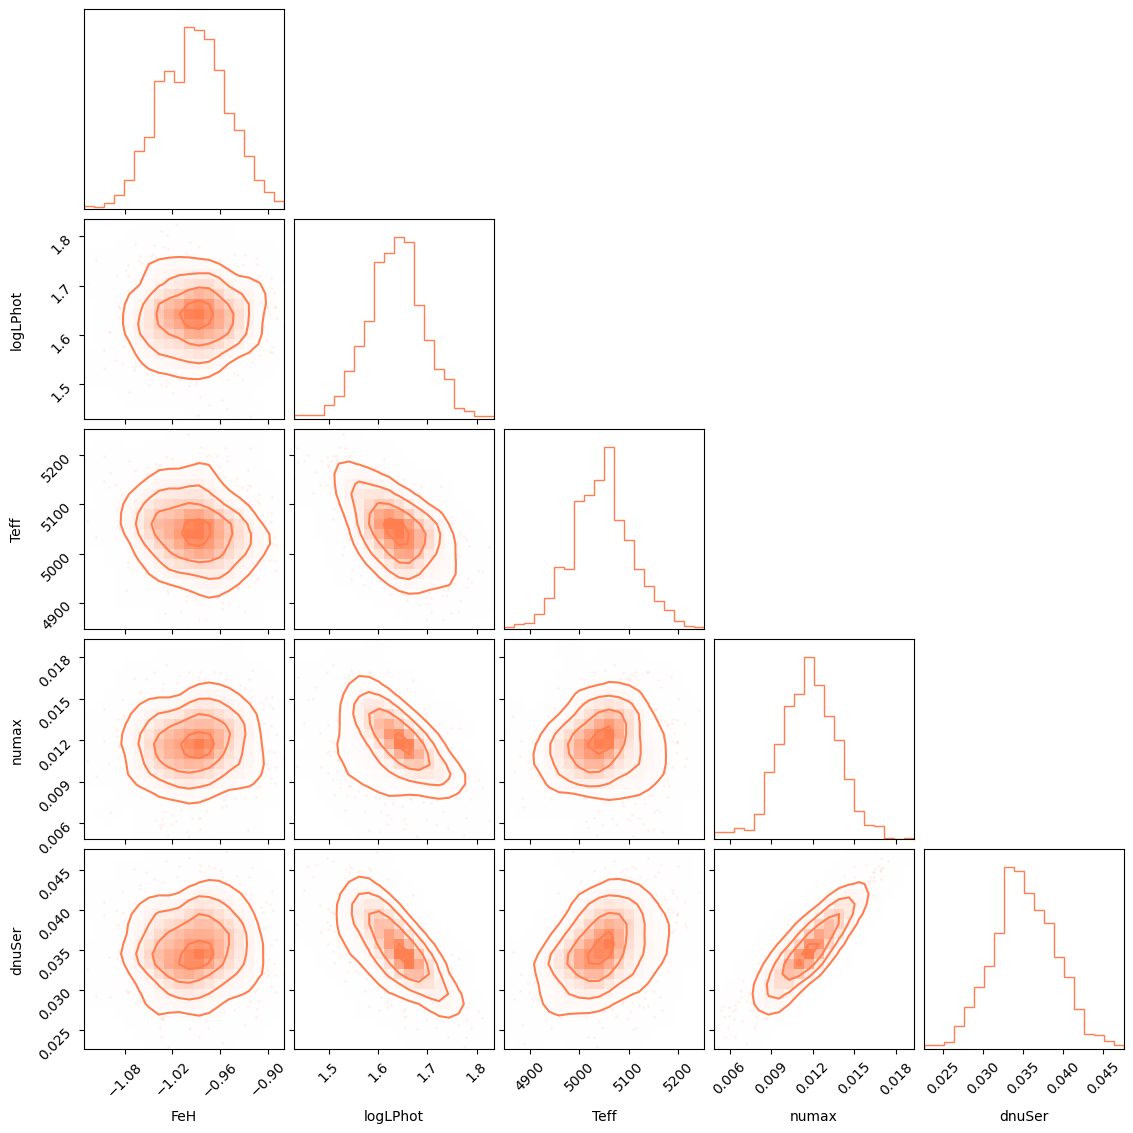

In [34]:
fig = corner.corner(cluster_df[model_outputs.outputs], smooth = True, color = 'coral')
fig.savefig('../figs/fake-cluster-observations-from-one-hare-outputs-corner.png', bbox_inches = 'tight')
plt.show()

(array([2., 3., 3., 4., 4., 8., 1., 2., 1., 2.]),
 array([0.00149865, 0.001558  , 0.00161735, 0.0016767 , 0.00173604,
        0.00179539, 0.00185474, 0.00191409, 0.00197344, 0.00203278,
        0.00209213]),
 <BarContainer object of 10 artists>)

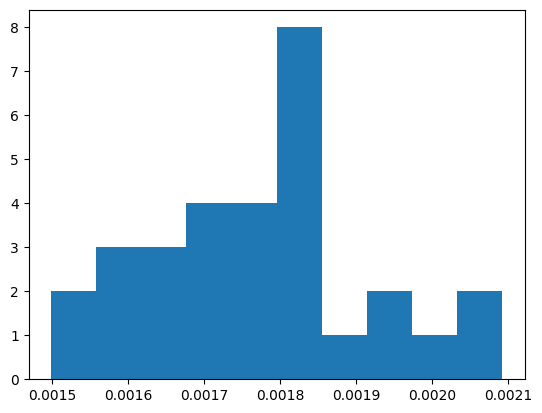

In [27]:
plt.hist(draws['zini'])

In [32]:
np.std(draws['yini'])

np.float64(0.0029308469484462013)

In [30]:
0.1*0.29

0.028999999999999998